In [46]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Rectangle

In [47]:
# --- Paths ---
# INR (data-driven) results
meta_dir = '../models/MetaLearning_MAML_DataDriven_h5/MetaMAML_1000it_h5_../data/healthy/HV06_05mm3_20ms_LR_sv12_tSNR10_newMask.h5_loadMetaInitTrue_20260212-1600'
nometa_dir = '../models/MetaLearning_MAML_DataDriven_h5/MetaMAML_1000it_h5_../data/healthy/HV06_05mm3_20ms_LR_sv12_tSNR10_newMask.h5_loadMetaInitFalse_20260212-1602'

# PINN results
pinn_meta_dir = '../models/MetaLearn_PINN_1000it_h5/MetaMAML_1000it_PINN_h5_../data/healthy/HV06_05mm3_20ms_LR_sv12_tSNR10_newMask.h5_loadMetaInitTrue_20260216-1508'
pinn_nometa_dir = '../models/MetaLearn_PINN_1000it_h5/MetaMAML_1000it_PINN_h5_../data/healthy/HV06_05mm3_20ms_LR_sv12_tSNR10_newMask.h5_loadMetaInitFalse_20260216-1516'

hr_path = '../data/healthy/HV06_05mm3_20ms.h5'
lr_path = '../data/healthy/HV06_05mm3_20ms_LR_sv12_tSNR10_newMask.h5'

iterations = [10, 25, 50, 100, 250, 500, 1000]


plane = 'z'
z_start = 41
full_slice = False
meas = 'w'
t_index = 2

vmin = 0.00
vmax = 0.57
cmap = 'viridis'

# Zoomed ROI
x_start = 88
y_start = 42
dim = 16

In [48]:
def load_slice(h5_path, meas, t_index, plane, slice_idx, full_slice=True,
               x_start=0, y_start=0, dim=72):
    """Load a 2D cross-section from an h5 file."""
    with h5py.File(h5_path, 'r') as f:
        if t_index is not None:
            data_3d = f[meas][t_index]
        else:
            data_3d = f[meas][0]
        
        if full_slice:
            if plane == 'x':
                slice_2d = data_3d[slice_idx, :, :]
            elif plane == 'y':
                slice_2d = data_3d[:, slice_idx, :]
            else:  # z
                slice_2d = data_3d[:, :, slice_idx]
        else:
            if plane == 'x':
                slice_2d = data_3d[slice_idx,
                                   y_start:y_start+dim,
                                   x_start:x_start+dim]
            elif plane == 'y':
                slice_2d = data_3d[x_start:x_start+dim,
                                   slice_idx,
                                   y_start:y_start+dim]
            else:  # z
                slice_2d = data_3d[x_start:x_start+dim,
                                   y_start:y_start+dim,
                                   slice_idx]
        
        return np.array(slice_2d)

## Side-by-side comparison: Meta Init vs Random Init across iterations

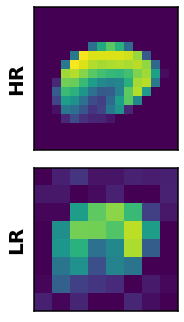

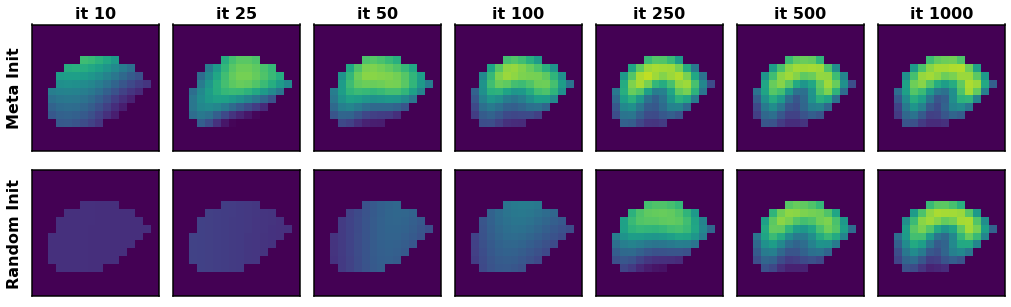

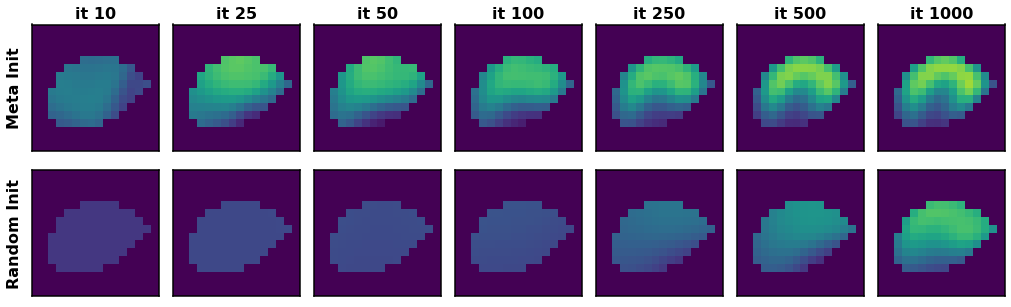

In [49]:
from scipy.ndimage import zoom as ndzoom

slice_idx = z_start

# Load HR slice
hr_slice = load_slice(hr_path, meas, t_index, plane, slice_idx, full_slice, x_start, y_start, dim)

# Load LR slice (halved indices) and upscale 2x nearest-neighbor
lr_slice_raw = load_slice(lr_path, meas, t_index // 2, plane, slice_idx // 2,
                          full_slice, x_start // 2, y_start // 2, dim // 2)
lr_slice = ndzoom(lr_slice_raw, 2, order=0)

# Load INR SR predictions
inr_meta_files = [os.path.join(meta_dir, f'SR_it{it:06d}.h5') for it in iterations]
inr_nometa_files = [os.path.join(nometa_dir, f'SR_it{it:06d}.h5') for it in iterations]
inr_meta_slices = [load_slice(f, meas, t_index, plane, slice_idx, full_slice, x_start, y_start, dim)
                   for f in inr_meta_files]
inr_nometa_slices = [load_slice(f, meas, t_index, plane, slice_idx, full_slice, x_start, y_start, dim)
                     for f in inr_nometa_files]

# Load PINN SR predictions
pinn_meta_files = [os.path.join(pinn_meta_dir, f'SR_it{it:06d}.h5') for it in iterations]
pinn_nometa_files = [os.path.join(pinn_nometa_dir, f'SR_it{it:06d}.h5') for it in iterations]
pinn_meta_slices = [load_slice(f, meas, t_index, plane, slice_idx, full_slice, x_start, y_start, dim)
                    for f in pinn_meta_files]
pinn_nometa_slices = [load_slice(f, meas, t_index, plane, slice_idx, full_slice, x_start, y_start, dim)
                      for f in pinn_nometa_files]

def style_ax(ax):
    """Add black outline border and remove ticks."""
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])

def plot_iterations(meta_slices, nometa_slices, title_prefix, save_name):
    """Plot 2 rows x 7 cols iteration comparison."""
    ncols = len(iterations)
    fig, axes = plt.subplots(2, ncols, figsize=(ncols * 2.5, 2 * 2.5))
    for row, (label, slices) in enumerate([
        ('Meta Init', meta_slices),
        ('Random Init', nometa_slices),
    ]):
        for col, sl in enumerate(slices):
            ax = axes[row, col]
            ax.imshow(sl.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax,
                      interpolation='nearest', aspect='equal')
            style_ax(ax)
            if row == 0:
                ax.set_title(f'it {iterations[col]}', fontsize=16, fontweight='bold')
            if col == 0:
                ax.set_ylabel(label, fontsize=16, fontweight='bold', rotation=90, labelpad=10)
    fig.subplots_adjust(wspace=0.08, hspace=0.15)
    fig.savefig(save_name, bbox_inches='tight')
    plt.show()
    plt.close(fig)

os.makedirs('2D_plots', exist_ok=True)

# ============================================================
# FIGURE 1: HR / LR reference (2 rows x 1 col)
# ============================================================
fig1, axes1 = plt.subplots(2, 1, figsize=(2.8, 2 * 2.8))
for ax, sl, label in zip(axes1, [hr_slice, lr_slice], ['HR', 'LR']):
    ax.imshow(sl.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax,
              interpolation='nearest', aspect='equal')
    ax.set_ylabel(label, fontsize=20, fontweight='bold', rotation=90, labelpad=8)
    style_ax(ax)
fig1.subplots_adjust(hspace=0.12)
fig1.savefig(f'2D_plots/HV06_reference_z{slice_idx}_t{t_index}.svg', bbox_inches='tight')
plt.show()
plt.close(fig1)

# ============================================================
# FIGURE 2: INR iterations — Meta Init vs Random Init
# ============================================================
plot_iterations(inr_meta_slices, inr_nometa_slices, 'INR',
                f'2D_plots/HV06_INR_iterations_z{slice_idx}_t{t_index}.svg')

# ============================================================
# FIGURE 3: PINN iterations — Meta Init vs Random Init
# ============================================================
plot_iterations(pinn_meta_slices, pinn_nometa_slices, 'PINN',
                f'2D_plots/HV06_PINN_iterations_z{slice_idx}_t{t_index}.svg')

## Absolute error vs HR ground truth

NameError: name 'meta_slices' is not defined

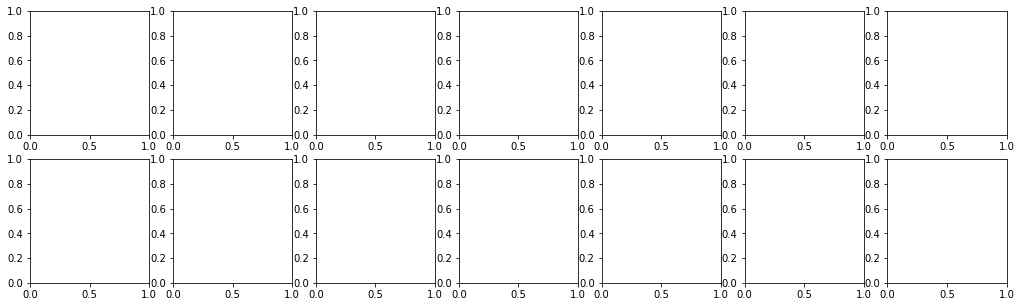

In [50]:
# Difference plots: |prediction - HR|
fig, axes = plt.subplots(2, len(iterations), figsize=(len(iterations) * 2.5, 2 * 2.5))

diff_max = 0
for slices in [meta_slices, nometa_slices]:
    for sl in slices:
        diff_max = max(diff_max, np.max(np.abs(sl - hr_slice)))

for row, (label, slices) in enumerate([
    ('Meta Init', meta_slices),
    ('Random Init', nometa_slices),
]):
    for col, sl in enumerate(slices):
        ax = axes[row, col]
        diff = np.abs(sl - hr_slice)
        im = ax.imshow(diff.T, cmap='hot', origin='lower',
                       vmin=0, vmax=diff_max, interpolation='nearest',
                       aspect='equal')
        ax.axis('off')
        if row == 0:
            ax.set_title(f'it {iterations[col]}', fontsize=10)
        if col == 0:
            ax.set_ylabel(label, fontsize=11, rotation=90, labelpad=10)
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

fig.subplots_adjust(right=0.92, wspace=0.05, hspace=0.15)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='|error| [m/s]')

fig.suptitle(f'HV06 — Absolute error vs HR (z={slice_idx}, t={t_index}, zoomed ROI)',
             fontsize=12, y=1.02)

plt.savefig(f'2D_plots/HV06_meta_vs_nometa_error_z{slice_idx}_t{t_index}_zoomed.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()